`seaborn` is a plotting library that sits on top of matplotlib and gives us ready-made chart types for exploring data, like histograms, joint plots, and pair plots, without having to build them piece by piece. `matplotlib.pyplot` is the lower-level plotting library seaborn is built on, and we still need it directly for small things like arranging multiple plots next to each other.

**Usecase:** Whenever you want to quickly explore a dataset visually, you start by importing these two so all the plotting functions used later in the notebook are available.

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

We use distribution plots to visualize the distribution of quantitative data.

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot/histplot
* jointplot
* pairplot
* rugplot

`sns.load_dataset('tips')` pulls in one of seaborn's built-in sample datasets and hands it back to us as a pandas DataFrame, which is just a table with rows and columns. Seaborn keeps a few small practice datasets like this so you always have real-looking data to try plots on without hunting for your own file.

**Usecase:** Here it loads restaurant bill data (columns like `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`) that every plot in the rest of the notebook is built from.

In [3]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


`.unique()` is a pandas method that looks at a single column and returns each distinct value in it exactly once, in the order it first appears.

**Usecase:** Before using a column to color or group a plot, it's good to check what values it actually holds. Here it confirms that the `size` column (number of people at the table) only contains a small set of whole numbers, which is why it works well later as a category in the pairplot's `hue`.

In [10]:
df['size'].unique()

array([2, 3, 4, 1, 6, 5])

`plt.subplot(1,2,1)` and `plt.subplot(1,2,2)` split the figure into a grid of 1 row and 2 columns, and pick which of those two spots the next plot should be drawn into. `sns.histplot(data, bins=20, kde=True)` draws a histogram, meaning it groups the numbers into 20 buckets ("bins") and shows how many values fall in each one as bars. `kde=True` adds a smooth curve on top that estimates the overall shape of the distribution without the choppiness of individual bars.

**Usecase:** Placing two histograms side by side lets you compare the shape of `total_bill` and `tip` at the same time, for example noticing that both are lopsided toward lower amounts with a few large outliers.

<Axes: xlabel='tip', ylabel='Count'>

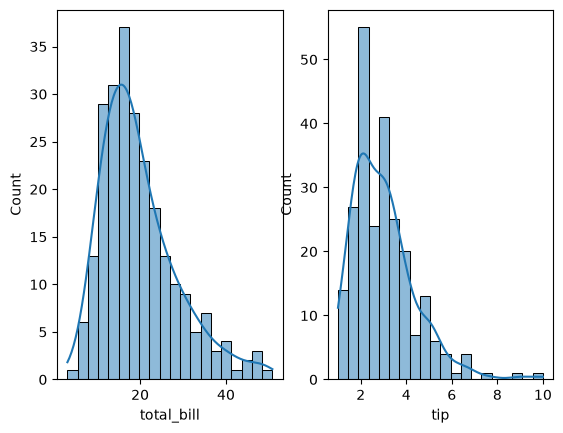

In [18]:
plt.subplot(1,2,1)
sns.histplot(df['total_bill'],bins = 20, kde = True)

plt.subplot(1,2,2)
sns.histplot(df['tip'],bins = 20,kde = True)

`sns.jointplot(x=..., y=..., data=..., kind='scatter')` puts a scatter plot of two columns in the middle (one dot per row of data), and adds a small histogram of each column along the top and right edges. So you get the relationship between the two columns and each column's own shape in one picture.

**Usecase:** Used here to see whether `total_bill` and `tip` move together, for instance whether bigger bills tend to come with bigger tips, while also seeing how each one is distributed on its own.

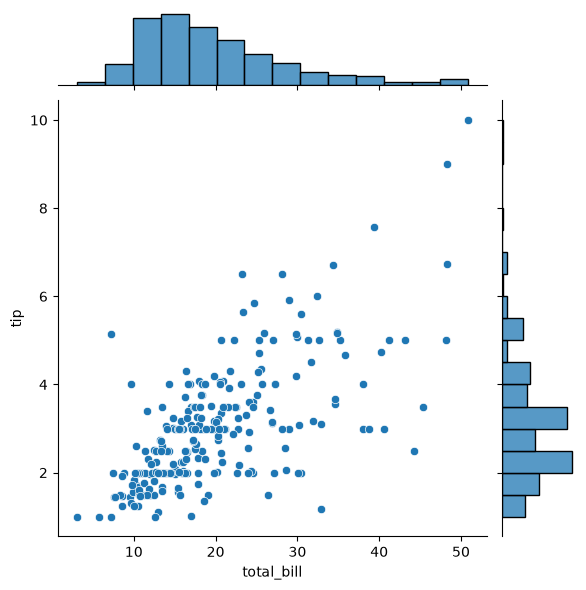

In [ ]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df, kind = 'scatter')

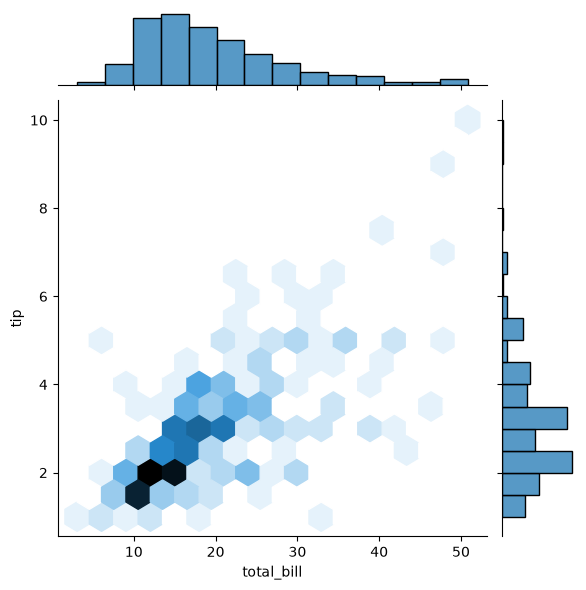

In [19]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df, kind = 'hex')

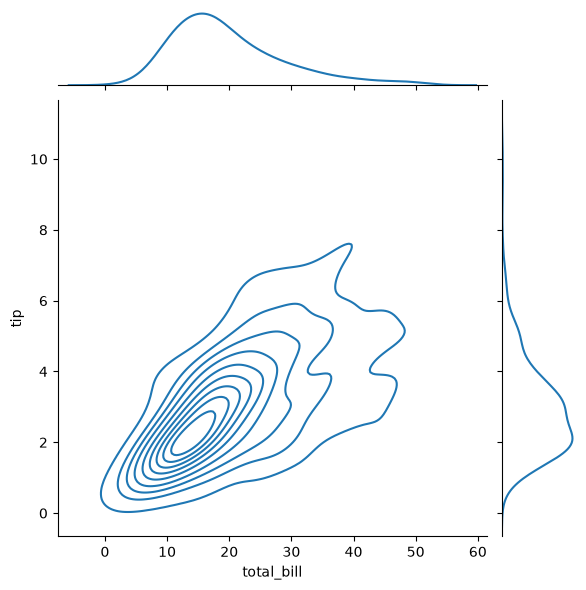

In [20]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df, kind = 'kde')

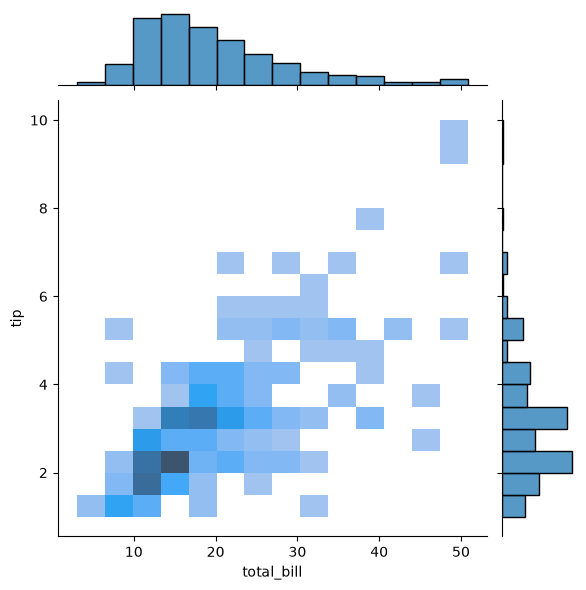

In [21]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df, kind = 'hist')

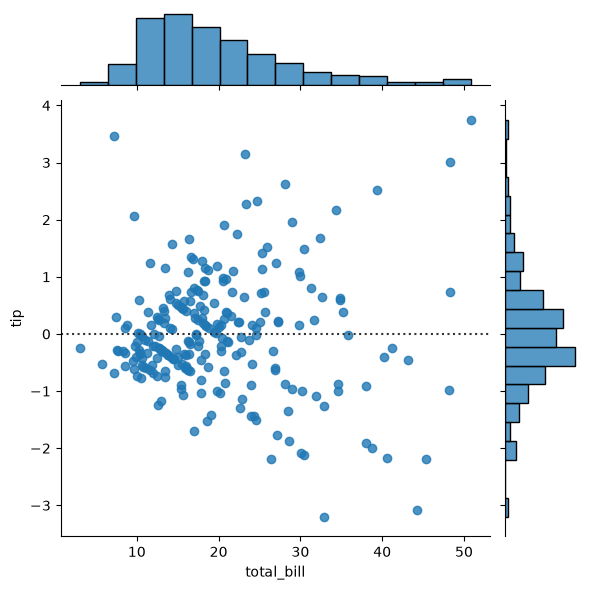

In [22]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df, kind = 'resid')

This is the same `sns.jointplot`, but `kind='reg'` additionally fits a straight line through the scatter points (a simple linear regression) and shades the area of uncertainty around it, on top of everything the scatter kind already shows.

**Usecase:** The straight line makes it easy to answer "as the bill goes up, does the tip generally go up too, and roughly by how much" just by looking at the slope of the line.

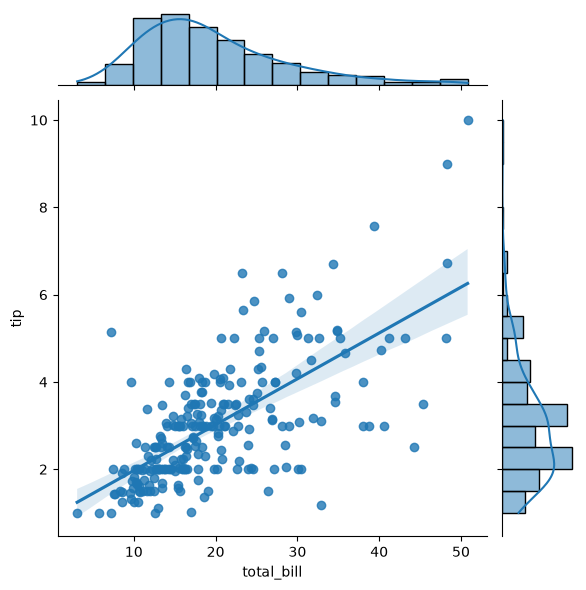

In [23]:
sns.jointplot(x = 'total_bill', y = 'tip', data = df,kind = 'reg')

`sns.pairplot(df, hue='size', palette='rainbow')` takes every numeric column in the table and plots each one against every other one, all arranged in a grid automatically. The boxes on the diagonal show each column's own distribution, and the rest show scatter plots between pairs of columns. `hue='size'` colors every point based on the `size` column, and `palette='rainbow'` just picks which set of colors to use for that coloring.

**Usecase:** This is a fast way to eyeball how all the numeric columns relate to each other at once, and here it also shows whether the number of people at the table (`size`) seems to change the pattern between bill amount and tip.

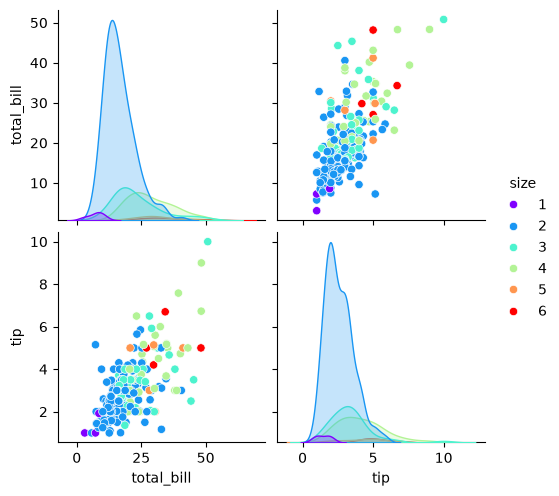

In [24]:
sns.pairplot(df,hue='size',palette='rainbow')

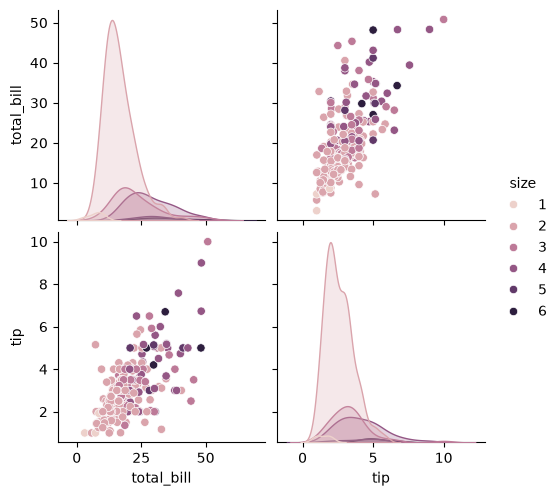

In [28]:
sns.pairplot(df, hue="size")

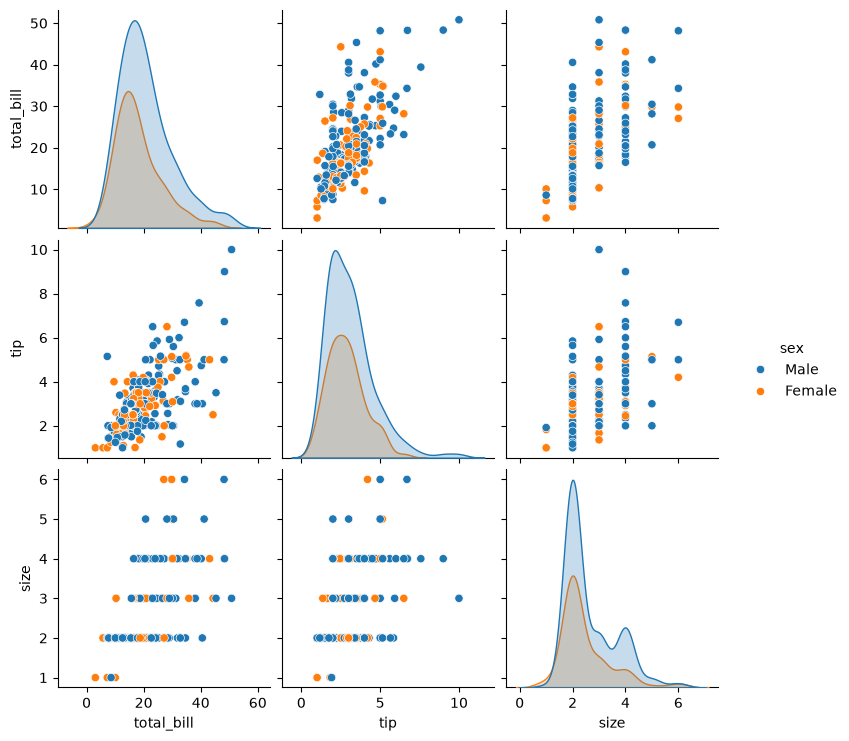

In [27]:
sns.pairplot(df, hue="sex")

`sns.rugplot(df['tip'])` draws one small tick mark on the x-axis for every single value in the `tip` column, with no grouping or smoothing at all.

**Usecase:** It's usually paired with a histogram or KDE curve to double-check that the smoothed picture isn't hiding where the data points are actually bunched up or missing.

<Axes: xlabel='tip'>

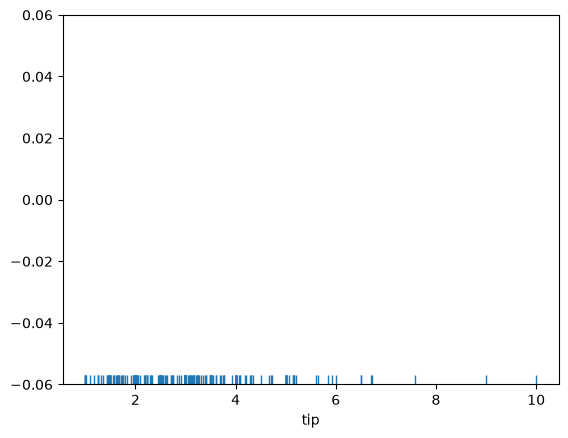

In [29]:
sns.rugplot(df['tip'])